Saved: /blue/jsampath/avemula/Paper1_PE/Polymer/rdf_plots/rdf_2x2_compact_ACS_same_ylabel_gap.png
Saved: /blue/jsampath/avemula/Paper1_PE/Polymer/rdf_plots/rdf_2x2_compact_ACS_same_ylabel_gap.pdf


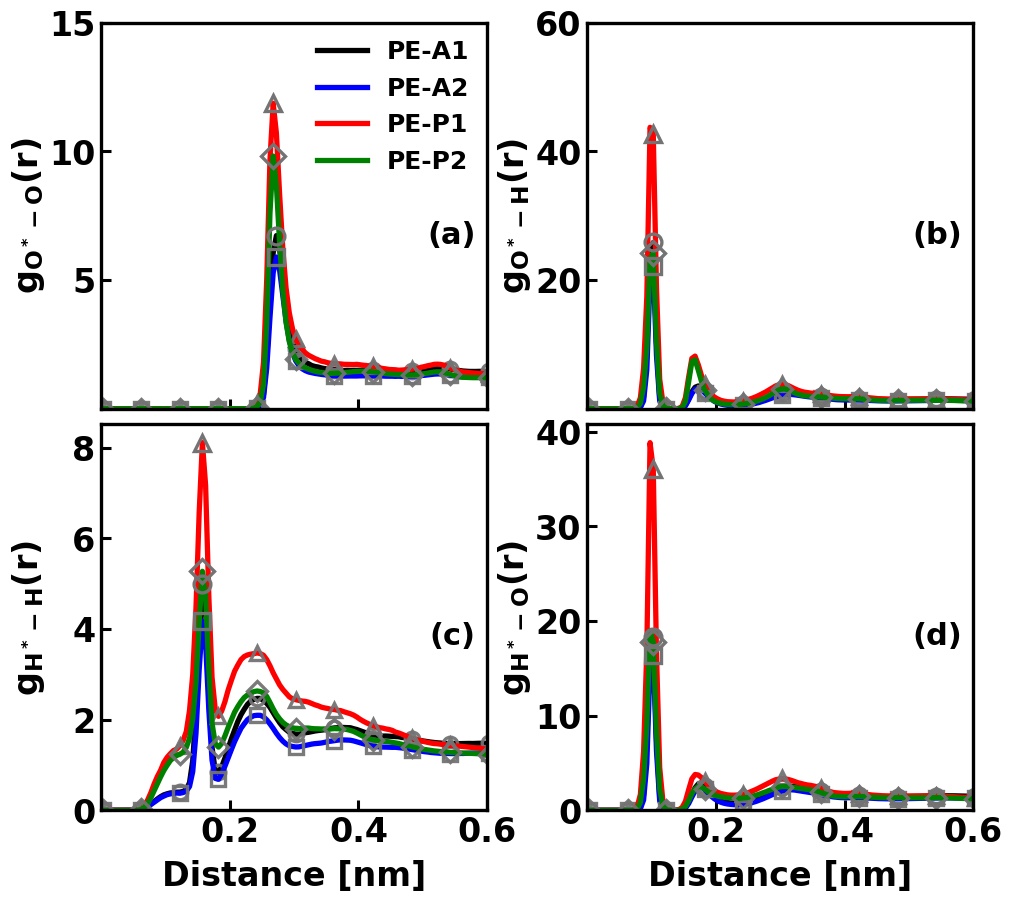

In [ ]:
#!/usr/bin/env python3
"""
Compact ACS-style 2x2 RDF panel plot



Features:
- 4 RDF panels in 2x2 layout
- compact spacing without overlap
- ticks only on left and bottom axes
- x tick labels only on bottom row
- y-axis labels on BOTH left and right columns
- same spacing between y-axis label and y-tick labels in BOTH columns
- removes only the y=0 tick label from TOP ROW plots
- removes x=0 tick label from bottom row plots
- axis label size == tick label size
- bold ACS-like style
- square-looking panels
- first-peak markers with sketch/pencil style

Each CSV must have columns:
    r_Angstrom, g_mean, g_std
"""

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================
# INPUT PATHS
# =========================
PANEL1_FILES = {
    "PE-A1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/rdf_pe_a1_out/PE-A1_mean_std_rdf.csv",
    "PE-A2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/rdf_pe_a2_out/PE-A2_mean_std_rdf.csv",
    "PE-P1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/rdf_pe_p1_out/PE-P1_mean_std_rdf.csv",
    "PE-P2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/rdf_pe_p2_out/PE-P2_mean_std_rdf.csv",
}

PANEL2_FILES = {
    "PE-A1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/rdf_OH_O_W_h/PE-A1_mean_std_rdf.csv",
    "PE-A2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/rdf_OH_O_W_h/PE-A2_mean_std_rdf.csv",
    "PE-P1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/rdf_OH_O_W_h/PE-P1_mean_std_rdf.csv",
    "PE-P2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/rdf_OH_O_W_h/PE-P2_mean_std_rdf.csv",
}

PANEL3_FILES = {
    "PE-A1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/rdf_OH_h_W_h/PE-A1_mean_std_rdf.csv",
    "PE-A2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/rdf_OH_h_W_h/PE-A2_mean_std_rdf.csv",
    "PE-P1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "PE-P2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/rdf_OH_h_W_h/PE-P2_mean_std_rdf.csv",
}

PANEL4_FILES = {
    "PE-A1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/rdf_OH_H_W_O/PE-A1_mean_std_rdf.csv",
    "PE-A2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/rdf_OH_H_W_O/PE-A2_mean_std_rdf.csv",
    "PE-P1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/rdf_OH_H_W_O/PE-P1_mean_std_rdf.csv",
    "PE-P2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/rdf_OH_H_W_O/PE-P2_mean_std_rdf.csv",
}

PANELS = [
    dict(tag="(a)", files=PANEL1_FILES, ylab=r"$g_{O^*-O}(r)$"),
    dict(tag="(b)", files=PANEL2_FILES, ylab=r"$g_{O^*-H}(r)$"),
    dict(tag="(c)", files=PANEL3_FILES, ylab=r"$g_{H^*-H}(r)$"),
    dict(tag="(d)", files=PANEL4_FILES, ylab=r"$g_{H^*-O}(r)$"),
]

# =========================
# OUTPUT
# =========================
OUTDIR = "/blue/jsampath/avemula/Paper1_PE/Polymer/rdf_plots"
OUTNAME = "rdf_2x2_compact_ACS_same_ylabel_gap"

# =========================
# AXIS SETTINGS
# =========================
XMAX_NM = 0.5
YMIN = 0.0
YMAX = None
XLABEL = "Distance [nm]"

PEAK_XMIN_NM = 0.10
PEAK_XMAX_NM = 0.35
MARK_EVERY = 12

# =========================
# STYLE
# =========================
LINEWIDTH = 3.8
MS = 10.5
MEW = 2.4
MARKER_GREY = "0.45"

STYLE = {
    "PE-A1": dict(color="k", marker="o"),
    "PE-A2": dict(color="b", marker="s"),
    "PE-P1": dict(color="r", marker="^"),
    "PE-P2": dict(color="g", marker="D"),
}

SHOW_STD_SHADE = False
SHADE_ALPHA = 0.18

# =========================
# "PENCIL" SETTINGS
# =========================
SKETCH_SCALE = 0.8
SKETCH_LENGTH = 60.0
SKETCH_RANDOMNESS = 2.0

# =========================
# FONT / ACS-LIKE STYLE
# =========================
FONT_FAMILY = "DejaVu Sans"
LABEL_SIZE = 24
TICK_SIZE = 24
LEGEND_SIZE = 18
PANEL_TAG_SIZE = 22

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": TICK_SIZE,
    "font.weight": "bold",
    "axes.labelsize": LABEL_SIZE,
    "axes.labelweight": "bold",
    "axes.linewidth": 2.4,
    "lines.linewidth": LINEWIDTH,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 2.2,
    "ytick.major.width": 2.2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.6,
    "ytick.minor.width": 1.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

mpl.rcParams.update({
    "mathtext.fontset": "custom",
    "mathtext.rm": "DejaVu Sans",
    "mathtext.it": "DejaVu Sans:italic",
    "mathtext.bf": "DejaVu Sans:bold",
})
mpl.rcParams["mathtext.default"] = "regular"


def load_mean_std(csv_path: str):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing file: {csv_path}")

    data = np.genfromtxt(csv_path, delimiter=",", names=True)

    required_cols = {"r_Angstrom", "g_mean", "g_std"}
    found_cols = set(data.dtype.names if data.dtype.names is not None else [])
    missing = required_cols - found_cols
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {missing}")

    r_A = np.asarray(data["r_Angstrom"], dtype=float)
    g_mean = np.asarray(data["g_mean"], dtype=float)
    g_std = np.asarray(data["g_std"], dtype=float)

    return r_A, g_mean, g_std


def first_peak_in_window(x, y, xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    if not np.any(mask):
        return None

    idx = np.where(mask)[0]
    ip = idx[np.argmax(y[mask])]
    return x[ip], y[ip]


def make_ticklabels_bold(ax):
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)


def remove_zero_from_bottom_xlabels(ax):
    xticks = ax.get_xticks()
    labels = []
    for x in xticks:
        if np.isclose(x, 0.0):
            labels.append("")
        else:
            labels.append(f"{x:g}")
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels)


def remove_zero_from_toprow_ylabels(ax):
    yticks = ax.get_yticks()
    labels = []
    for y in yticks:
        if np.isclose(y, 0.0):
            labels.append("")
        else:
            labels.append(f"{y:g}")
    ax.set_yticks(yticks)
    ax.set_yticklabels(labels)


def format_axes(ax, ylab=None, show_xlabel=False, show_xticklabels=True):
    for spine in ax.spines.values():
        spine.set_linewidth(mpl.rcParams["axes.linewidth"])

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=4
    )

    ax.set_xlim(0, XMAX_NM)
    ax.set_ylim(bottom=YMIN)

    if YMAX is not None:
        ax.set_ylim(YMIN, YMAX)

    if show_xlabel:
        ax.set_xlabel(XLABEL, fontweight="bold", labelpad=8)
    else:
        ax.set_xlabel("")

    if ylab is not None:
        ax.set_ylabel(ylab, fontweight="bold")

    # SAME ylabel-to-ticks spacing for both left and right columns
    ax.yaxis.set_label_coords(-0.14, 0.5)

    ax.tick_params(labelbottom=show_xticklabels, labelleft=True)

    ax.set_box_aspect(1)
    make_ticklabels_bold(ax)

    if show_xticklabels:
        remove_zero_from_bottom_xlabels(ax)


def main():
    os.makedirs(OUTDIR, exist_ok=True)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10.4, 8.8),
        sharex=True,
        sharey=False
    )
    axes = axes.flatten()

    for i, (ax, panel) in enumerate(zip(axes, PANELS)):
        for label, path in panel["files"].items():
            r_A, g_mean, g_std = load_mean_std(path)
            r_nm = r_A / 10.0
            st = STYLE[label]

            ax.plot(
                r_nm, g_mean,
                color=st["color"],
                lw=LINEWIDTH,
                label=label if i == 0 else None
            )

            marker_artist, = ax.plot(
                r_nm, g_mean,
                linestyle="None",
                marker=st["marker"],
                markevery=MARK_EVERY,
                markersize=MS,
                markerfacecolor="none",
                markeredgecolor=MARKER_GREY,
                markeredgewidth=MEW,
                alpha=0.95
            )
            marker_artist.set_sketch_params(
                scale=SKETCH_SCALE,
                length=SKETCH_LENGTH,
                randomness=SKETCH_RANDOMNESS
            )

            if SHOW_STD_SHADE and np.any(g_std > 0):
                ax.fill_between(
                    r_nm,
                    g_mean - g_std,
                    g_mean + g_std,
                    color=st["color"],
                    alpha=SHADE_ALPHA,
                    linewidth=0
                )

            pk = first_peak_in_window(r_nm, g_mean, PEAK_XMIN_NM, PEAK_XMAX_NM)
            if pk is not None:
                xpk, ypk = pk
                peak_artist, = ax.plot(
                    [xpk], [ypk],
                    marker=st["marker"],
                    markersize=MS * 1.15,
                    markerfacecolor="none",
                    markeredgecolor=MARKER_GREY,
                    markeredgewidth=MEW,
                    linestyle="None",
                    zorder=10
                )
                peak_artist.set_sketch_params(
                    scale=SKETCH_SCALE,
                    length=SKETCH_LENGTH,
                    randomness=SKETCH_RANDOMNESS
                )

        ax.text(
            0.97, 0.45, panel["tag"],
            transform=ax.transAxes,
            fontsize=PANEL_TAG_SIZE,
            fontweight="bold",
            ha="right",
            va="center"
        )

        is_bottom = i in [2, 3]
        is_top = i in [0, 1]

        format_axes(
            ax,
            ylab=panel["ylab"],
            show_xlabel=is_bottom,
            show_xticklabels=is_bottom
        )

        if is_top:
            remove_zero_from_toprow_ylabels(ax)

    leg = axes[0].legend(
        frameon=False,
        loc="upper right",
        handlelength=2.0,
        borderaxespad=0.3
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
        t.set_fontfamily(FONT_FAMILY)

    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        bottom=0.09,
        top=0.985,
        hspace=0.04,
        wspace=0.12
    )

    png = os.path.join(OUTDIR, OUTNAME + ".png")
    pdf = os.path.join(OUTDIR, OUTNAME + ".pdf")

    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print("Saved:", png)
    print("Saved:", pdf)


if __name__ == "__main__":
    main()